In [1]:
from read_repo_data import read_repo_data
from split_markdown_by_level import split_markdown_by_level
from search import (
    text_search,
    vector_search,
    build_vector_index,
    search_vector_index,
    hybrid_search,
)
from sentence_transformers import SentenceTransformer

## Downloading data from the repository as a zip archive

In [2]:
transformers_docs = read_repo_data('huggingface', 'transformers', 'docs/source/en')

In [3]:
transformers_docs[1]

{'content': '<!--Copyright 2025 The HuggingFace Team. All rights reserved.\n\nLicensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with\nthe License. You may obtain a copy of the License at\n\nhttp://www.apache.org/licenses/LICENSE-2.0\n\nUnless required by applicable law or agreed to in writing, software distributed under the License is distributed on\nan "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the\nspecific language governing permissions and limitations under the License.\n\n⚠️ Note that this file is in Markdown but contains specific syntax for our doc-builder (similar to MDX) that may not be\nrendered properly in your Markdown viewer.\n\n-->\n\n# Accelerator selection\n\nDuring distributed training, you can specify the number and order of accelerators (CUDA, XPU, MPS, HPU, etc.) to use. This can be useful when you have accelerators with different computing po

In [4]:
print(f"Transformers English documents: {len(transformers_docs)}")

Transformers English documents: 657


## Splitting data into chunks by Headers 2

In [5]:
transformers_chunks = []

for doc in transformers_docs:
    doc_copy = doc.copy()
    doc_content = doc_copy.pop('content')
    sections = split_markdown_by_level(doc_content, level=2)
    for section in sections:
        section_doc = doc_copy.copy()
        section_doc['section'] = section
        transformers_chunks.append(section_doc)

[{'filename': 'transformers-main/docs/source/en/accelerate.md',
  'section': '<!--Copyright 2024 The HuggingFace Team. All rights reserved.\n\nLicensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with\nthe License. You may obtain a copy of the License at\n\nhttp://www.apache.org/licenses/LICENSE-2.0\n\nUnless required by applicable law or agreed to in writing, software distributed under the License is distributed on\nan "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the\nspecific language governing permissions and limitations under the License.\n\n⚠️ Note that this file is in Markdown but contain specific syntax for our doc-builder (similar to MDX) that may not be\nrendered properly in your Markdown viewer.\n\n-->\n\n# Accelerate\n\n[Accelerate](https://hf.co/docs/accelerate/index) is a library designed to simplify distributed training on any type of setup with PyTorch
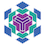

In [6]:
transformers_chunks

In [7]:
transformers_chunks[15]

{'filename': 'transformers-main/docs/source/en/add_new_model.md',
 'section': '## Implement processor\n\nIf your model accepts multiple modalities, like text and images, you need to add a processor. The processor centralizes the preprocessing of different modalities before passing them to the model.\n\nThe processor should call the appropriate modality-specific processors within its `__call__` function to handle each type of input correctly. Be sure to check existing processors in the library to understand their expected structure. Transformers uses the following convention in the `__call__` function signature.\n\n```python\ndef __call__(\n    self,\n    images: ImageInput = None,\n    text: Union[TextInput, PreTokenizedInput, list[TextInput], list[PreTokenizedInput]] = None,\n    audio=None,\n    videos=None,\n    **kwargs: Unpack[YourModelProcessorKwargs],\n) -> BatchFeature:\n    ...\n```\n\n`YourModelProcessorKwargs` is a `TypedDict` that includes all the typical processing argumen

## Search 

### Text search

In [8]:
query = 'How to do prompt engineering?'
fields = ['filename', 'section']
text_results = text_search(transformers_chunks, fields, query)

In [9]:
text_results

[{'filename': 'transformers-main/docs/source/en/tasks/text-to-speech.md',
  'section': '<!--Copyright 2023 The HuggingFace Team. All rights reserved.\n\nLicensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with\nthe License. You may obtain a copy of the License at\n\nhttp://www.apache.org/licenses/LICENSE-2.0\n\nUnless required by applicable law or agreed to in writing, software distributed under the License is distributed on\nan "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the\nspecific language governing permissions and limitations under the License.\n\n⚠️ Note that this file is in Markdown but contain specific syntax for our doc-builder (similar to MDX) that may not be\nrendered properly in your Markdown viewer.\n\n-->\n\n# Text to speech\n\n[[open-in-colab]]\n\nText-to-speech (TTS) is the task of creating natural-sounding speech from text, where the speech can be

### Vector search (the best one)

In [10]:
embedding_model = SentenceTransformer('multi-qa-distilbert-cos-v1')
vector_vindex = build_vector_index(transformers_chunks, embedding_model)
vector_results = search_vector_index(vector_vindex, embedding_model, query)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/154 [00:00<?, ?it/s]

In [11]:
vector_results

[{'filename': 'transformers-main/docs/source/en/tasks/prompting.md',
  'section': '## Best practices\n\n1. Try to pick the latest models for the best performance. Keep in mind that LLMs can come in two variants, [base](https://hf.co/mistralai/Mistral-7B-v0.1) and [instruction-tuned](https://hf.co/mistralai/Mistral-7B-Instruct-v0.1) (or chat).\n\n    Base models are excellent at completing text given an initial prompt, but they\'re not as good at following instructions. Instruction-tuned models are specifically trained versions of the base models on instructional or conversational data. This makes instruction-tuned models a better fit for prompting.\n\n    > [!WARNING]\n    > Modern LLMs are typically decoder-only models, but there are some encoder-decoder LLMs like [Flan-T5](../model_doc/flan-t5) or [BART](../model_doc/bart) that may be used for prompting. Load these models directly with the [`AutoModelForSeq2SeqLM`] class (instead of using [`Pipeline`]) and generate outputs from the m

### Hybrid search

In [12]:
hybrid_results = hybrid_search(text_results, vector_results, query)

In [13]:
hybrid_results

[{'filename': 'transformers-main/docs/source/en/tasks/text-to-speech.md',
  'section': '<!--Copyright 2023 The HuggingFace Team. All rights reserved.\n\nLicensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with\nthe License. You may obtain a copy of the License at\n\nhttp://www.apache.org/licenses/LICENSE-2.0\n\nUnless required by applicable law or agreed to in writing, software distributed under the License is distributed on\nan "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the\nspecific language governing permissions and limitations under the License.\n\n⚠️ Note that this file is in Markdown but contain specific syntax for our doc-builder (similar to MDX) that may not be\nrendered properly in your Markdown viewer.\n\n-->\n\n# Text to speech\n\n[[open-in-colab]]\n\nText-to-speech (TTS) is the task of creating natural-sounding speech from text, where the speech can be

## Pydantic AI agent


In [22]:
from repo_agent import create_repo_agent, ask_sync  # in notebooks you can also: from repo_agent import ask; await ask(...)

# query = 'What is the purpose of the pipeline() function in Transformers?'
query = 'How do you load a pretrained model from the Hub?'
repo_agent = create_repo_agent(transformers_chunks, embedding_model=embedding_model)
answer = ask_sync(repo_agent, query)  # needs OPENAI_API_KEY


Batches:   0%|          | 0/154 [00:00<?, ?it/s]

In [23]:
answer

'To load a pretrained model from the Hugging Face Hub, you can use the `from_pretrained` method of the `PreTrainedModel` class or its subclasses. Here are the steps:\n\n1. **Using AutoModel**: This is a convenient way to load a model for specific tasks without needing to know the exact model class name.\n\n   ```python\n   from transformers import AutoModelForCausalLM\n\n   # Loading a pretrained model for causal language modeling\n   model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-2-7b-hf")\n   ```\n\n   You can switch to other tasks or models easily with the same API:\n\n   ```python\n   model = AutoModelForSequenceClassification.from_pretrained("meta-llama/Llama-2-7b-hf")\n   model = AutoModelForQuestionAnswering.from_pretrained("meta-llama/Llama-2-7b-hf")\n   ```\n\n2. **Using Model-Specific Classes**: If you know the specific model class you want to use, you can load it directly.\n\n   ```python\n   from transformers import LlamaForCausalLM\n\n   model = LlamaForCau